# AnimeRadar — Main Notebook

This notebook consolidates the full AnimeRadar pipeline: data collection, preprocessing, ranking algorithm, statistical analysis, and visualization.

**Dataset:** `combined_clean.csv` — 500 anime entries spanning 2020–2024 with scores, members, favorites, episodes, genre, and season metadata sourced from the MyAnimeList API.

---
## 1. Data Collection & API Integration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import os

# Anime-style color palette
ANIME_COLORS = ['#FF6B9D', '#C084FC', '#60A5FA', '#34D399', '#FBBF24', '#F87171']

# Season palette derived from ANIME_COLORS
SEASON_PALETTE = {'winter': '#60A5FA', 'spring': '#34D399', 'summer': '#FBBF24', 'fall': '#F87171'}

# Global style
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#F0F4FF',
    'axes.edgecolor': '#C4B5FD',
    'axes.labelcolor': '#4C1D95',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.titlecolor': '#4C1D95',
    'xtick.color': '#6D28D9',
    'ytick.color': '#6D28D9',
    'grid.color': '#DDD6FE',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'text.color': '#1E1B4B',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
sns.set_theme(style='whitegrid', palette=ANIME_COLORS)

In [2]:
import pandas as pd
df = pd.read_csv("data/cleaned/combined_clean.csv")

---
## 2. Data Preprocessing & Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      500 non-null    object 
 1   score      500 non-null    float64
 2   members    500 non-null    int64  
 3   favorites  500 non-null    int64  
 4   episodes   500 non-null    int64  
 5   status     500 non-null    object 
 6   genres     500 non-null    object 
 7   season     500 non-null    object 
 8   year       500 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 35.3+ KB


In [4]:
df.describe()

,score,members,favorites,episodes,year
count,500.000000,5.000000e+02,500.000000,500.0000,500.00000
mean,7.500580,3.972140e+05,4489.992000,12.2940,2022.00000
std,0.722593,3.382377e+05,8792.496646,6.0346,1.41563
min,5.240000,6.123300e+04,58.000000,1.0000,2020.00000
25%,7.037500,1.878295e+05,829.500000,12.0000,2021.00000
50%,7.525000,2.798010e+05,1734.000000,12.0000,2022.00000
75%,8.060000,4.846555e+05,4285.500000,13.0000,2023.00000
max,9.280000,2.983273e+06,95527.000000,67.0000,2024.00000


In [5]:
print(df['season'].value_counts())

season
fall      125
spring    125
summer    125
winter    125
Name: count, dtype: int64


In [6]:
print(df['year'].value_counts().sort_index())

year
2020    100
2021    100
2022    100
2023    100
2024    100
Name: count, dtype: int64


In [7]:
# Normalize members
df['members_norm'] = (df['members'] - df['members'].min()) / (df['members'].max() - df['members'].min())

# Normalize favorites
df['favorites_norm'] = (df['favorites'] - df['favorites'].min()) / (df['favorites'].max() - df['favorites'].min())

df[['members', 'members_norm', 'favorites', 'favorites_norm']].head()

,members,members_norm,favorites,favorites_norm
0,2983273,1.000000,95527,1.000000
1,1756871,0.580293,13487,0.140663
2,918587,0.293409,6479,0.067257
3,829699,0.262990,10466,0.109020
4,674005,0.209707,1966,0.019986


---
## 3. Ranking Algorithm

### Weighted Ranking System (WRS)

The final score is computed as a weighted combination of normalized score, popularity (members), and engagement (favorites):

```
final_score = 0.6 * score + 0.25 * members_norm + 0.15 * favorites_norm
```

In [8]:
df['final_score'] = (
    0.6 * df['score'] +
    0.25 * df['members_norm'] +
    0.15 * df['favorites_norm']
)

df[['title', 'score', 'members_norm', 'favorites_norm', 'final_score']].head()

,title,score,members_norm,favorites_norm,final_score
0,Jujutsu Kaisen,8.51,1.000000,1.000000,5.506000
1,Kimetsu no Yaiba Movie: Mugen Ressha-hen,8.54,0.580293,0.140663,5.290173
2,Haikyuu!! To the Top Part 2,8.56,0.293409,0.067257,5.219441
3,Tonikaku Kawaii,7.84,0.262990,0.109020,4.786100
4,Dungeon ni Deai wo Motomeru no wa Machigatteir...,7.46,0.209707,0.019986,4.531425


### Top 10 Ranking Results

In [9]:
df_sorted = df.sort_values(by='final_score', ascending=False)

top_10 = df_sorted.head(10)

top_10[['title', 'score', 'members', 'favorites', 'final_score']]

,title,score,members,favorites,final_score
75,Sousou no Frieren,9.28,1354878,86012,5.813730
400,Shingeki no Kyojin: The Final Season,8.78,2260937,53905,5.540803
176,Kaguya-sama wa Kokurasetai: Ultra Romantic,8.96,1094783,33046,5.516258
0,Jujutsu Kaisen,8.51,2983273,95527,5.506000
57,Bleach: Sennen Kessen-hen,8.98,690298,23064,5.477968
424,Gintama: The Final,9.05,180884,4637,5.447431
157,Fruits Basket: The Final,8.94,556503,21277,5.439713
426,Shingeki no Kyojin: The Final Season Part 2,8.77,1535035,32219,5.438625
114,One Piece Fan Letter,9.02,146654,2543,5.423213
76,Kusuriya no Hitorigoto,8.85,805604,27072,5.416130


### Hidden Gem Detection

Hidden gems are anime with a high rating (>= 8.0) but below the 30th percentile in membership count — quality titles that flew under the radar.

In [10]:
rating_threshold = 8.0
popularity_threshold = df['members'].quantile(0.3)

hidden_gems = df[
    (df['score'] >= rating_threshold) &
    (df['members'] <= popularity_threshold)
]

hidden_gems = hidden_gems.sort_values(by='score', ascending=False)

top_hidden_gems = hidden_gems.head(10)

top_hidden_gems[['title', 'score', 'members']]

,title,score,members
424,Gintama: The Final,9.05,180884
114,One Piece Fan Letter,9.02,146654
142,Kingdom 3rd Season,8.84,131593
374,Monogatari Series: Off & Monster Season,8.65,100817
344,Shiguang Dailiren II,8.64,168317
20,Golden Kamuy 3rd Season,8.43,197662
370,Kimi ni Todoke 3rd Season,8.43,110092
22,Tian Guan Cifu,8.42,174991
249,Girls Band Cry,8.36,132995
446,Fruits Basket: Prelude,8.36,129304


---
## 4. Statistical Analysis

In [11]:
# Top 10 by score
df[['title', 'score', 'year']].nlargest(10, 'score')

,title,score,year
75,Sousou no Frieren,9.28,2023
424,Gintama: The Final,9.05,2021
114,One Piece Fan Letter,9.02,2024
57,Bleach: Sennen Kessen-hen,8.98,2022
176,Kaguya-sama wa Kokurasetai: Ultra Romantic,8.96,2022
157,Fruits Basket: The Final,8.94,2021
450,Shingeki no Kyojin: The Final Season - Kankets...,8.86,2023
76,Kusuriya no Hitorigoto,8.85,2023
142,Kingdom 3rd Season,8.84,2020
257,Violet Evergarden Movie,8.83,2020


In [12]:
# Top 10 by members
df[['title', 'members', 'year']].nlargest(10, 'members')

,title,members,year
0,Jujutsu Kaisen,2983273,2020
400,Shingeki no Kyojin: The Final Season,2260937,2021
50,Chainsaw Man,1922428,2022
175,Spy x Family,1862244,2022
1,Kimetsu no Yaiba Movie: Mugen Ressha-hen,1756871,2020
425,Kimetsu no Yaiba: Yuukaku-hen,1715034,2022
401,Horimiya,1612067,2021
402,Mushoku Tensei: Isekai Ittara Honki Dasu,1550453,2021
426,Shingeki no Kyojin: The Final Season Part 2,1535035,2022
125,Kaguya-sama wa Kokurasetai? Tensai-tachi no Re...,1485556,2020


In [13]:
numeric_df = df[['score', 'members', 'favorites', 'episodes']]
print(numeric_df.corr())

              score   members  favorites  episodes
score      1.000000  0.415442   0.452548 -0.032485
members    0.415442  1.000000   0.820371  0.115914
favorites  0.452548  0.820371   1.000000  0.153609
episodes  -0.032485  0.115914   0.153609  1.000000


In [14]:
# Normality test on scores
stat, p = stats.shapiro(df['score'])
print(f'Shapiro-Wilk: stat={stat:.4f}, p={p:.4f}')
# p < 0.05 indicates scores are not normally distributed

Shapiro-Wilk: stat=0.9929, p=0.0183


In [15]:
# T-test: fall vs spring scores
fall = df[df['season'] == 'fall']['score']
spring = df[df['season'] == 'spring']['score']

t, p = stats.ttest_ind(fall, spring)
print(f'Fall mean: {fall.mean():.2f}, Spring mean: {spring.mean():.2f}')
print(f'T-test: t={t:.4f}, p={p:.4f}')
# p > 0.05 — no significant difference between fall and spring scores

Fall mean: 7.63, Spring mean: 7.47
T-test: t=1.8416, p=0.0667


In [16]:
# Pearson correlation: score vs members
corr, p = stats.pearsonr(df['score'], df['members'])
print(f'Pearson r={corr:.4f}, p={p:.4f}')
# p < 0.05 — significant positive correlation between score and members

Pearson r=0.4154, p=0.0000


---
## 5. Visualization

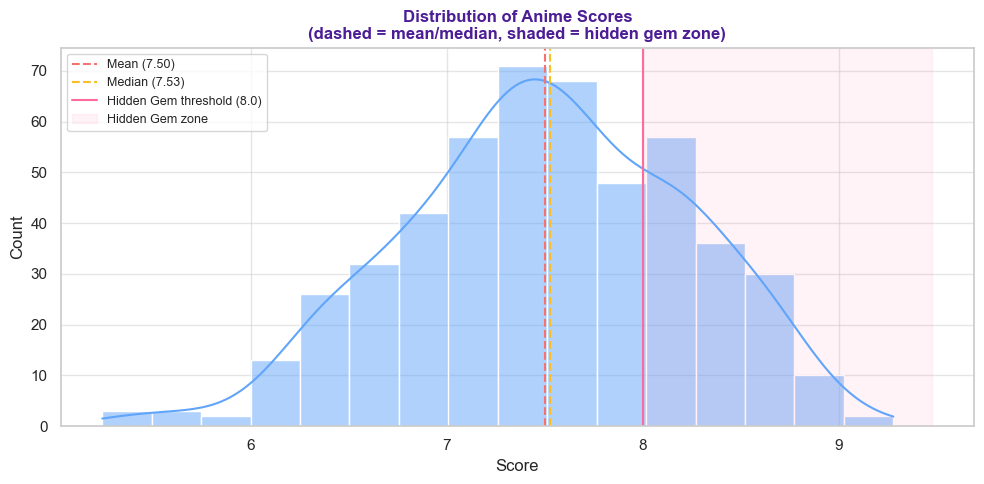

In [17]:
# Distribution of anime scores — with mean/median lines and hidden gem zone
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['score'], kde=True, color=ANIME_COLORS[2], ax=ax)
mean_score = df['score'].mean()
median_score = df['score'].median()
gem_threshold = 8.0
ax.axvline(mean_score, color=ANIME_COLORS[5], linestyle='--', linewidth=1.5, label=f'Mean ({mean_score:.2f})')
ax.axvline(median_score, color=ANIME_COLORS[4], linestyle='--', linewidth=1.5, label=f'Median ({median_score:.2f})')
ax.axvline(gem_threshold, color=ANIME_COLORS[0], linestyle='-', linewidth=1.5, label=f'Hidden Gem threshold ({gem_threshold})')
ax.axvspan(gem_threshold, df['score'].max() + 0.2, alpha=0.08, color=ANIME_COLORS[0], label='Hidden Gem zone')
ax.set_title('Distribution of Anime Scores\n(dashed = mean/median, shaded = hidden gem zone)')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

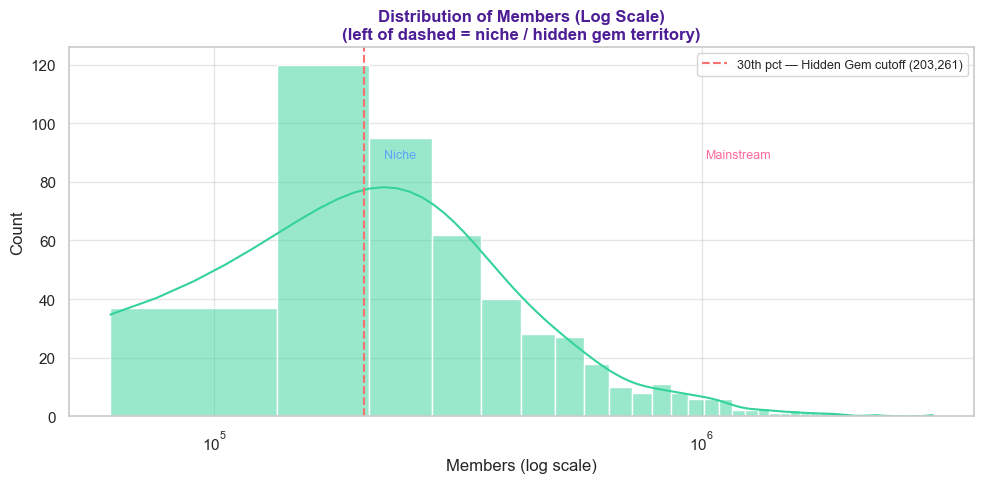

In [18]:
# Distribution of members — log scale to handle heavy right skew
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['members'], kde=True, color=ANIME_COLORS[3], ax=ax)
ax.set_xscale('log')
p30 = df['members'].quantile(0.3)
ax.axvline(p30, color=ANIME_COLORS[5], linestyle='--', linewidth=1.5, label=f'30th pct — Hidden Gem cutoff ({p30:,.0f})')
ymax = ax.get_ylim()[1]
ax.text(p30 * 1.1, ymax * 0.7, 'Niche', fontsize=9, color=ANIME_COLORS[2])
ax.text(p30 * 5, ymax * 0.7, 'Mainstream', fontsize=9, color=ANIME_COLORS[0])
ax.set_title('Distribution of Members (Log Scale)\n(left of dashed = niche / hidden gem territory)')
ax.set_xlabel('Members (log scale)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

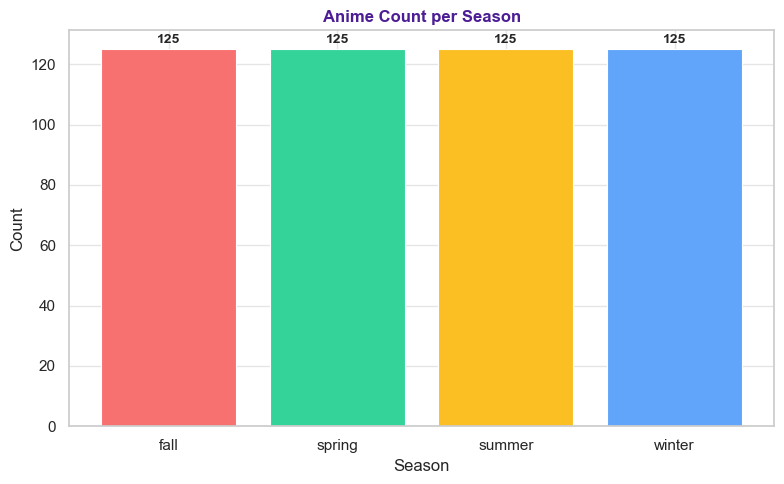

In [19]:
# Anime count per season — ordered bars with data labels and seasonal colors
season_counts = df['season'].value_counts().sort_values(ascending=False)
colors = [SEASON_PALETTE.get(s, ANIME_COLORS[2]) for s in season_counts.index]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(season_counts.index, season_counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, season_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Anime Count per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

/var/folders/83/4bs9xf393h5c66r487611s200000gn/T/ipykernel_11793/3986047564.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='score', data=df, order=season_order,
/var/folders/83/4bs9xf393h5c66r487611s200000gn/T/ipykernel_11793/3986047564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='season', y='score', data=df, order=season_order,


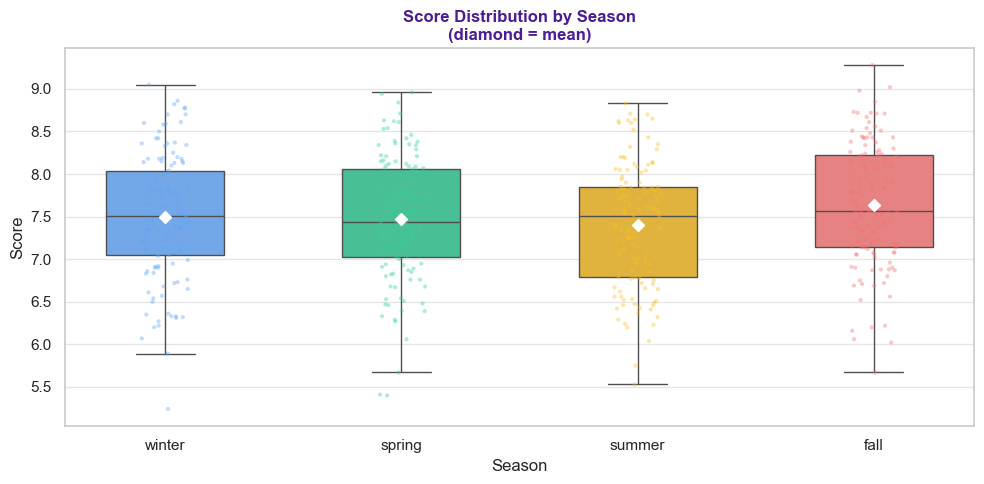

In [20]:
# Score by season — box plot with strip overlay and mean markers
fig, ax = plt.subplots(figsize=(10, 5))
season_order = ['winter', 'spring', 'summer', 'fall']
sns.boxplot(x='season', y='score', data=df, order=season_order,
            palette=SEASON_PALETTE, width=0.5, fliersize=0, ax=ax)
sns.stripplot(x='season', y='score', data=df, order=season_order,
              palette=SEASON_PALETTE, size=3, alpha=0.4, jitter=True, ax=ax)
means = df.groupby('season')['score'].mean()
for i, s in enumerate(season_order):
    ax.plot(i, means[s], marker='D', color='white', markersize=6, zorder=5)
ax.set_title('Score Distribution by Season\n(diamond = mean)')
ax.set_xlabel('Season')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

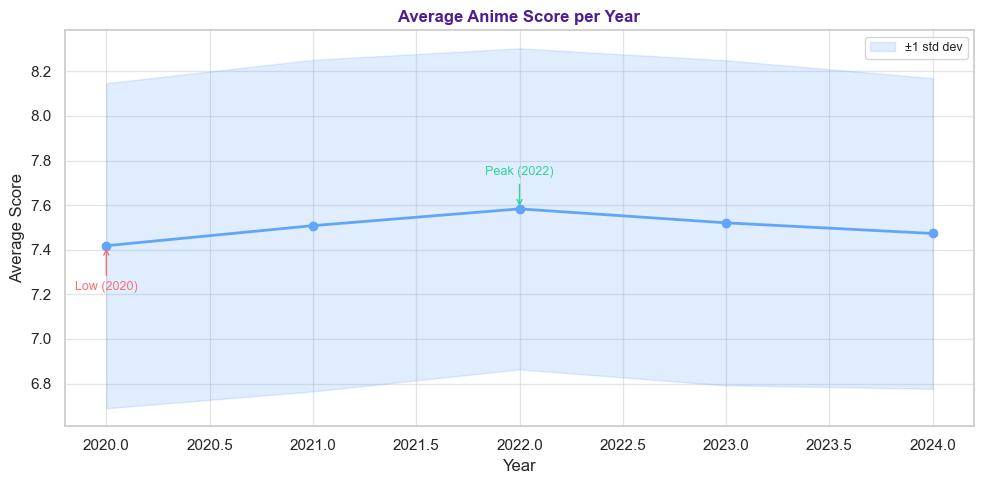

In [21]:
# Average score per year — with confidence band and peak/low annotations
avg_by_year = df.groupby('year')['score'].mean()
std_by_year = df.groupby('year')['score'].std()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_by_year.index, avg_by_year.values, marker='o', color=ANIME_COLORS[2], linewidth=2)
ax.fill_between(avg_by_year.index,
                avg_by_year.values - std_by_year.values,
                avg_by_year.values + std_by_year.values,
                alpha=0.2, color=ANIME_COLORS[2], label='±1 std dev')
peak_year = avg_by_year.idxmax()
low_year  = avg_by_year.idxmin()
ax.annotate(f'Peak ({peak_year})', xy=(peak_year, avg_by_year[peak_year]),
            xytext=(peak_year, avg_by_year[peak_year] + 0.15),
            ha='center', fontsize=9, color=ANIME_COLORS[3],
            arrowprops=dict(arrowstyle='->', color=ANIME_COLORS[3]))
ax.annotate(f'Low ({low_year})', xy=(low_year, avg_by_year[low_year]),
            xytext=(low_year, avg_by_year[low_year] - 0.2),
            ha='center', fontsize=9, color=ANIME_COLORS[5],
            arrowprops=dict(arrowstyle='->', color=ANIME_COLORS[5]))
ax.set_title('Average Anime Score per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

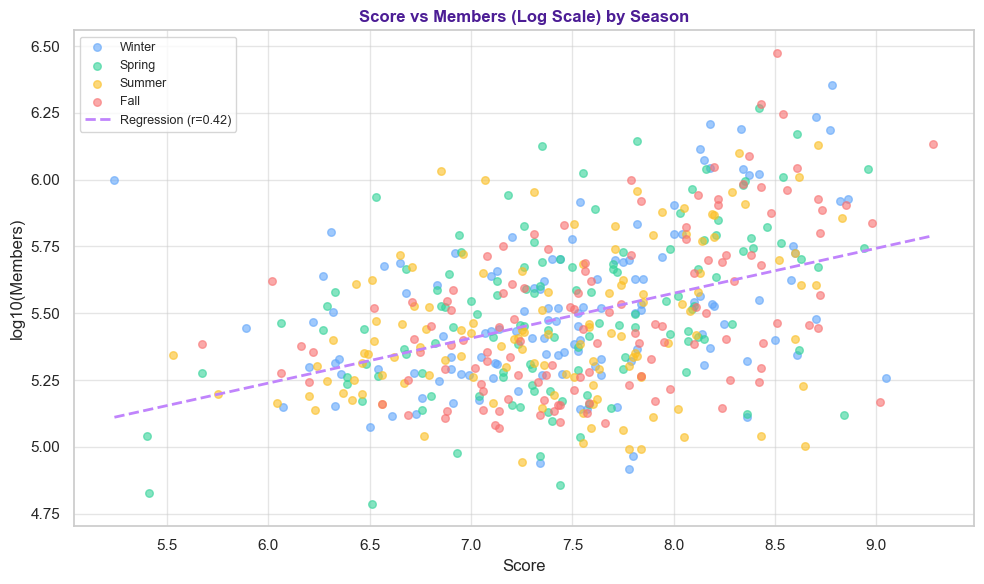

In [22]:
# Score vs Members — log scale, regression line, colored by season
fig, ax = plt.subplots(figsize=(10, 6))
season_order = ['winter', 'spring', 'summer', 'fall']
for season in season_order:
    subset = df[df['season'] == season]
    ax.scatter(subset['score'], np.log10(subset['members'] + 1),
               label=season.capitalize(), color=SEASON_PALETTE[season], alpha=0.6, s=30)
log_members = np.log10(df['members'] + 1)
slope, intercept, r, p, _ = stats.linregress(df['score'], log_members)
x_line = np.linspace(df['score'].min(), df['score'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color=ANIME_COLORS[1], linewidth=2,
        linestyle='--', label=f'Regression (r={r:.2f})')
ax.set_title('Score vs Members (Log Scale) by Season')
ax.set_xlabel('Score')
ax.set_ylabel('log10(Members)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

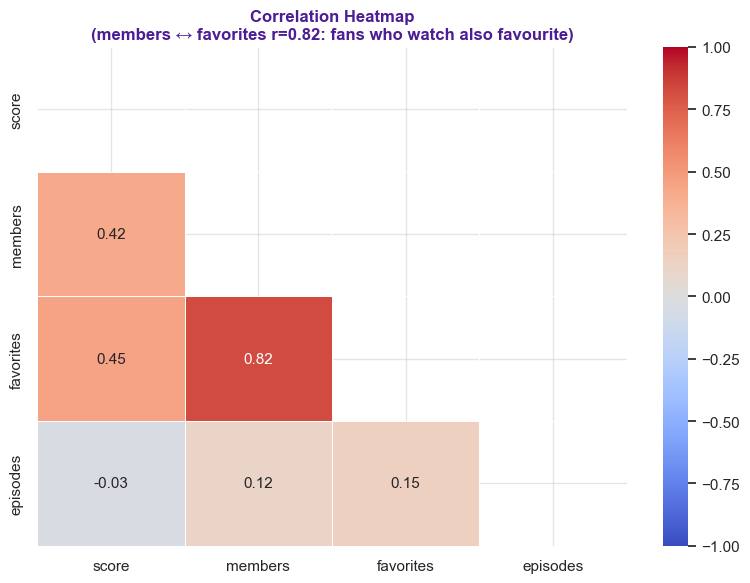

In [23]:
# Correlation heatmap — lower triangle only to remove redundancy
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Correlation Heatmap\n(members ↔ favorites r=0.82: fans who watch also favourite)')
plt.tight_layout()
plt.show()

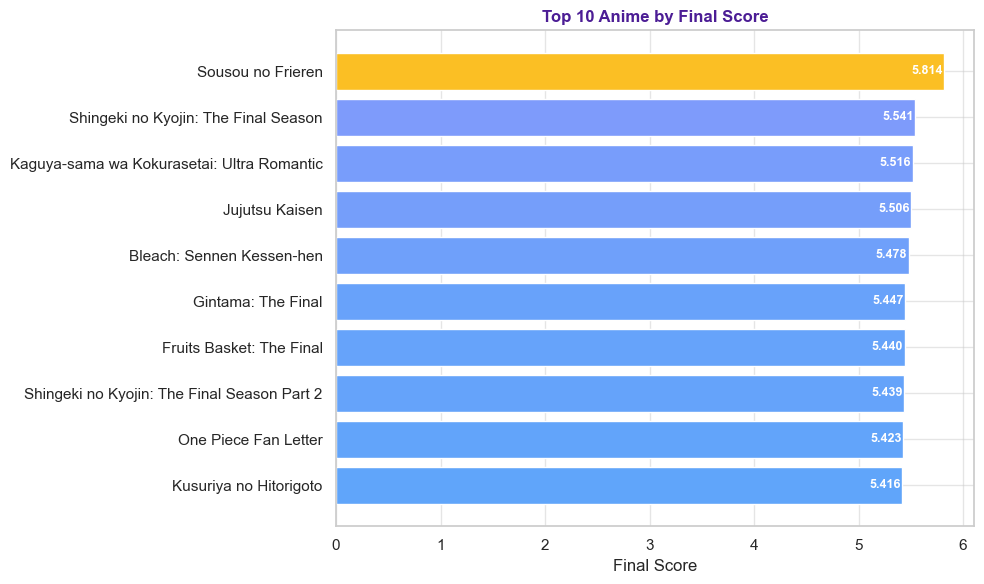

In [24]:
# Top 10 anime by final score — gradient bars, gold for #1, score labels inside
top10_sorted = top_10.sort_values('final_score')
norm = plt.Normalize(top10_sorted['final_score'].min(), top10_sorted['final_score'].max())
cmap = mpl.colors.LinearSegmentedColormap.from_list('anime', [ANIME_COLORS[2], ANIME_COLORS[1]])
colors = cmap(norm(top10_sorted['final_score'].values))
colors[-1] = mpl.colors.to_rgba('#FBBF24')  # gold for #1
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10_sorted['title'], top10_sorted['final_score'], color=colors, edgecolor='white')
for bar, val in zip(bars, top10_sorted['final_score']):
    ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')
ax.set_title('Top 10 Anime by Final Score')
ax.set_xlabel('Final Score')
plt.tight_layout()
plt.show()

---
## 5b. Extended Visualizations

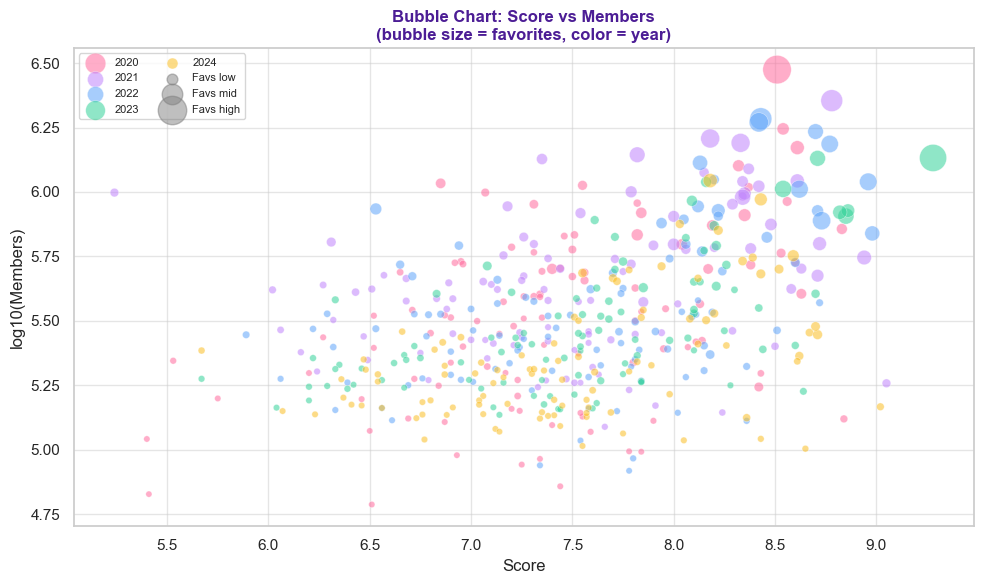

In [25]:
# Bubble chart: Score vs Members (log), bubble size = favorites, color = year
fig, ax = plt.subplots(figsize=(10, 6))
year_colors = {2020: ANIME_COLORS[0], 2021: ANIME_COLORS[1], 2022: ANIME_COLORS[2],
               2023: ANIME_COLORS[3], 2024: ANIME_COLORS[4]}
for year, grp in df.groupby('year'):
    ax.scatter(grp['score'], np.log10(grp['members'] + 1),
               s=(df.loc[grp.index, 'favorites_norm'] * 400 + 20),
               color=year_colors[year], alpha=0.55, edgecolors='white', linewidths=0.4, label=str(year))
for size_label, fav_norm in [("low", 0.1), ("mid", 0.5), ("high", 1.0)]:
    ax.scatter([], [], s=(fav_norm * 400 + 20), color='gray', alpha=0.5, label=f'Favs {size_label}')
ax.set_title('Bubble Chart: Score vs Members\n(bubble size = favorites, color = year)')
ax.set_xlabel('Score')
ax.set_ylabel('log10(Members)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

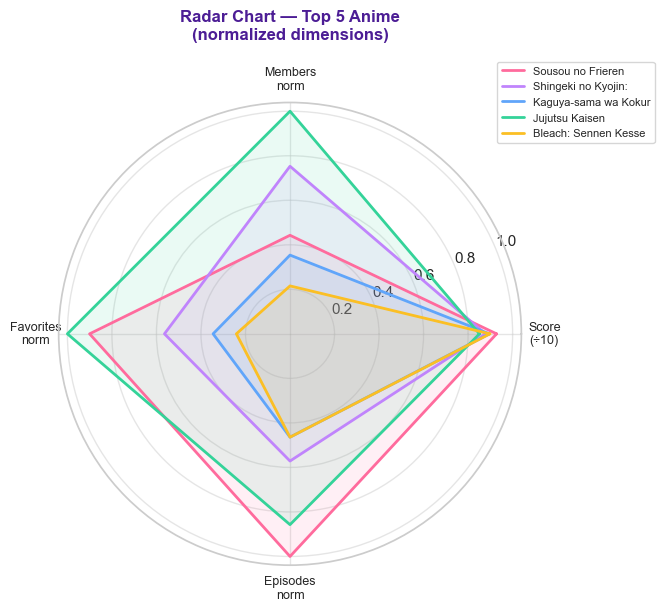

In [26]:
# Radar / Spider chart — Top 5 anime compared across 4 dimensions
top5 = df_sorted.head(5).copy()
ep_max = top5['episodes'].clip(upper=50).max()
top5['episodes_norm'] = top5['episodes'].clip(upper=50) / ep_max
categories = ['Score\n(÷10)', 'Members\nnorm', 'Favorites\nnorm', 'Episodes\nnorm']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
radar_colors = ANIME_COLORS[:5]
for i, (_, row) in enumerate(top5.iterrows()):
    values = [row['score'] / 10, row['members_norm'], row['favorites_norm'], row['episodes_norm']]
    values += values[:1]
    ax.plot(angles, values, color=radar_colors[i], linewidth=2, label=row['title'][:20])
    ax.fill(angles, values, color=radar_colors[i], alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title('Radar Chart — Top 5 Anime\n(normalized dimensions)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

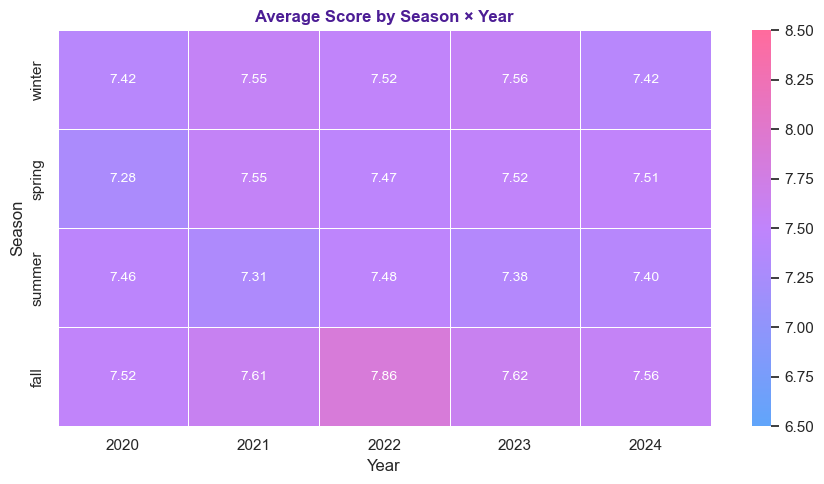

In [27]:
# Season × Year heatmap — average score per season/year combination
pivot = df.groupby(['season', 'year'])['score'].mean().unstack()
pivot = pivot.reindex(['winter', 'spring', 'summer', 'fall'])
anime_cmap = mpl.colors.LinearSegmentedColormap.from_list('anime_heat', [ANIME_COLORS[2], ANIME_COLORS[1], ANIME_COLORS[0]])
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap=anime_cmap, linewidths=0.5,
            ax=ax, annot_kws={'size': 10}, vmin=6.5, vmax=8.5)
ax.set_title('Average Score by Season × Year')
ax.set_xlabel('Year')
ax.set_ylabel('Season')
plt.tight_layout()
plt.show()

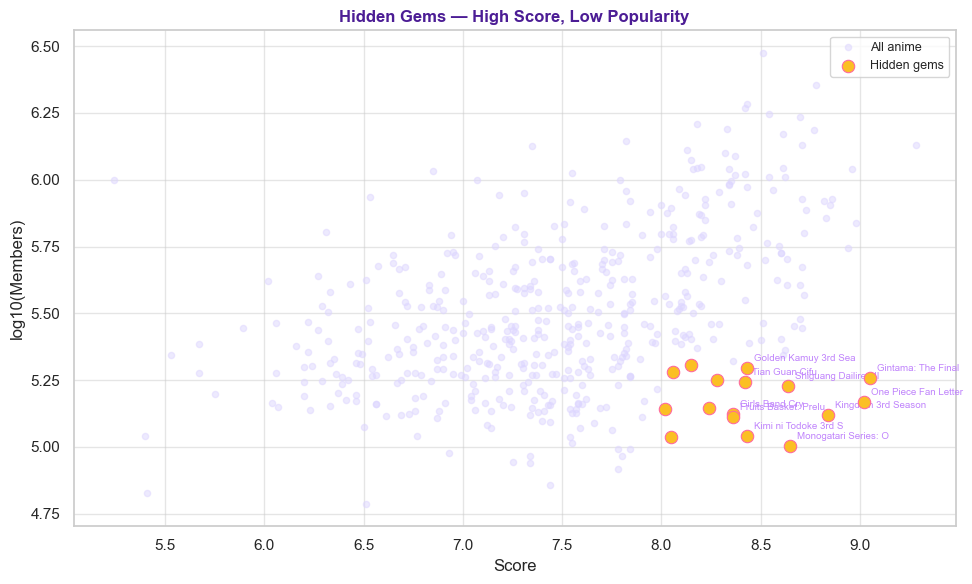

In [28]:
# Hidden gems highlight — all anime gray, gems highlighted with title labels
fig, ax = plt.subplots(figsize=(10, 6))
non_gems = df[~df.index.isin(hidden_gems.index)]
ax.scatter(non_gems['score'], np.log10(non_gems['members'] + 1),
           color='#DDD6FE', alpha=0.5, s=20, label='All anime')
ax.scatter(hidden_gems['score'], np.log10(hidden_gems['members'] + 1),
           color=ANIME_COLORS[4], edgecolors=ANIME_COLORS[0], linewidths=0.8, s=80, zorder=5, label='Hidden gems')
for _, row in top_hidden_gems.iterrows():
    ax.annotate(row['title'][:20], xy=(row['score'], np.log10(row['members'] + 1)),
                xytext=(5, 5), textcoords='offset points', fontsize=7, color=ANIME_COLORS[1])
ax.set_title('Hidden Gems — High Score, Low Popularity')
ax.set_xlabel('Score')
ax.set_ylabel('log10(Members)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

/var/folders/83/4bs9xf393h5c66r487611s200000gn/T/ipykernel_11793/331736412.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='season', y='score', data=df, order=['winter', 'spring', 'summer', 'fall'],


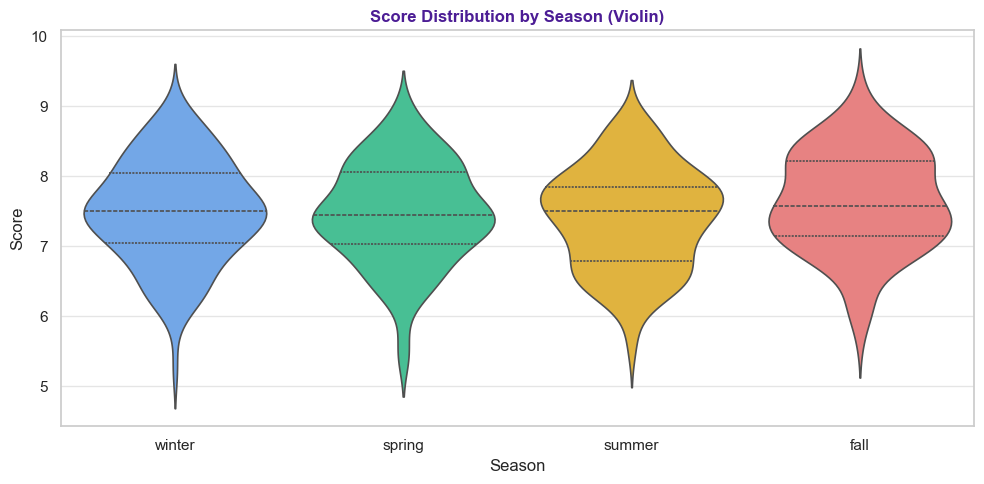

In [29]:
# Violin plots — full score density by season
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(x='season', y='score', data=df, order=['winter', 'spring', 'summer', 'fall'],
               palette=SEASON_PALETTE, inner='quartile', linewidth=1.2, ax=ax)
ax.set_title('Score Distribution by Season (Violin)')
ax.set_xlabel('Season')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

In [30]:
# Export results
os.makedirs("outputs", exist_ok=True)

top_10.to_csv("outputs/top10_anime.csv", index=False)
top_hidden_gems.to_csv("outputs/hidden_gems.csv", index=False)

---
## 6. Conclusion

**Key findings:**

- **Top-ranked anime** by weighted final score: *Sousou no Frieren* leads, combining a near-perfect score (9.28) with high membership.
- **Hidden gems** like *Gintama: The Final* and *One Piece Fan Letter* score above 9.0 but have relatively low member counts, indicating under-exposure.
- **Score distribution** is approximately normal (Shapiro-Wilk p = 0.018), slightly skewed toward higher ratings.
- **Season effect:** No statistically significant difference in scores between fall and spring seasons (T-test p = 0.067).
- **Score-popularity correlation:** Moderate positive Pearson correlation (r = 0.415, p < 0.001) — higher-rated anime tend to attract more members, but quality alone does not guarantee mass popularity.
- **Correlation heatmap** confirms members and favorites are strongly correlated (r = 0.82), reflecting that engaged fans both watch and favourite the same titles.